# Siamese / Triplet iResNet50 — One-Shot Face Verification

Supports two training modes:
- **Siamese** (default): BCE + contrastive loss with progressive margin + hard mining
- **Triplet**: Batch-hard triplet loss (FaceNet-style) with PK-sampling

**Outputs** (saved to `models/face_recognition/siamese/results/`):
- `training_history.png` — loss/metric chart per epoch
- `verification_roc.png` — ROC curve each verification run
- `verification_distribution.png` — same/diff score distribution
- `checkpoints/latest/` — last 2 full checkpoints (for resume)
- `checkpoints/best/` — best val_loss checkpoint
- `best_backbone.h5` — backbone weights for inference
- `best_siamese.h5` or `best_triplet.h5` — full model weights

In [1]:
import os, sys

# Train from project root
PROJECT_ROOT = r"C:\Users\Admin\Desktop\Project_DAT301m"
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)

# ── Configuration ──────────────────────────
MODE = "siamese"

CONFIG = {
    # Data paths
    "dataset_dir": "dataset_final/train",
    "val_dir":     "dataset_final/val",
    "test_dir":    "dataset_ms1m/test",

    # Training (shared)
    "batch_size":        100,           # Siamese batch size
    "epochs":            120,
    "img_size":          112,
    "embedding_dim":     512,
    "dropout":           0.4,
    "lr":                0.0005,       # Lower LR for stability
    "pairs_per_epoch":   200000,       # Siamese only
    "val_pairs":         10000,
    "patience":          30,
    "warmup_epochs":     5,
    "seed":              42,

    # Siamese specific
    "loss_type":         MODE,
    "contrastive_weight": 0.3,
    "margin_start":      0.4,
    "margin_end":        0.15,         # NOT zero — prevents embedding collapse
    "hard_mine_every":    3,
    "hard_mine_start":    10,
    "hard_mine_samples":  5000,
    "hard_mine_topk":     200,
    "hard_ratio_start":   0.1,
    "hard_ratio_end":     0.3,         # Max 30% hard negatives — avoids label noise

    # Triplet specific
    "p_per_batch":              40,
    "k_per_id":                 5,
    "triplet_margin":           0.3,
    "triplet_batches_per_epoch": 1000,

    # Verification evaluation
    "verify_every":       3,
    "verify_pairs":       2000,

    # Resume
    "resume":             True,
}

print(f"Configuration loaded [{MODE.upper()} mode].")
print(f"  Dataset:         {CONFIG['dataset_dir']}")
print(f"  Val:             {CONFIG['val_dir']}")
print(f"  Test:            {CONFIG['test_dir']}")
print(f"  Batch size:      {CONFIG['batch_size']}")
print(f"  Epochs:          {CONFIG['epochs']}")
print(f"  LR:              {CONFIG['lr']}")
print(f"  Margin:          {CONFIG['margin_start']} -> {CONFIG['margin_end']}")
print(f"  Hard ratio:      {CONFIG['hard_ratio_start']} -> {CONFIG['hard_ratio_end']}")
print(f"  Resume:          {CONFIG['resume']}")
print(f"  Mixed precision: ON (mixed_float16)")

Configuration loaded [SIAMESE mode].
  Dataset:         dataset_final/train
  Val:             dataset_final/val
  Test:            dataset_ms1m/test
  Batch size:      100
  Epochs:          120
  LR:              0.0005
  Margin:          0.4 -> 0.15
  Hard ratio:      0.1 -> 0.3
  Resume:          True
  Mixed precision: ON (mixed_float16)


In [2]:
import sys, json, os, math
import tensorflow as tf

from models.face_recognition.siamese import train

# Build argument list
args_list = [
    'train_siamese.ipynb',
    '--dataset_dir',     CONFIG['dataset_dir'],
    '--val_dir',         CONFIG['val_dir'],
    '--test_dir',        CONFIG['test_dir'],
    '--loss_type',       CONFIG['loss_type'],
    '--batch_size',      str(CONFIG['batch_size']),
    '--epochs',          str(CONFIG['epochs']),
    '--img_size',        str(CONFIG['img_size']),
    '--embedding_dim',   str(CONFIG['embedding_dim']),
    '--dropout',         str(CONFIG['dropout']),
    '--lr',              str(CONFIG['lr']),
    '--pairs_per_epoch', str(CONFIG['pairs_per_epoch']),
    '--val_pairs',       str(CONFIG['val_pairs']),
    '--patience',        str(CONFIG['patience']),
    '--warmup_epochs',   str(CONFIG['warmup_epochs']),
    '--seed',            str(CONFIG['seed']),
    '--verify_every',    str(CONFIG['verify_every']),
    '--verify_pairs',    str(CONFIG['verify_pairs']),
]

# Mode-specific args
if CONFIG['loss_type'] == 'siamese':
    args_list.extend([
        '--contrastive_weight', str(CONFIG['contrastive_weight']),
        '--margin_start',       str(CONFIG['margin_start']),
        '--margin_end',         str(CONFIG['margin_end']),
        '--hard_mine_every',    str(CONFIG['hard_mine_every']),
        '--hard_mine_start',    str(CONFIG['hard_mine_start']),
        '--hard_mine_samples',  str(CONFIG['hard_mine_samples']),
        '--hard_mine_topk',     str(CONFIG['hard_mine_topk']),
        '--hard_ratio_start',   str(CONFIG['hard_ratio_start']),
        '--hard_ratio_end',     str(CONFIG['hard_ratio_end']),
    ])
else:
    args_list.extend([
        '--p_per_batch',              str(CONFIG['p_per_batch']),
        '--k_per_id',                 str(CONFIG['k_per_id']),
        '--triplet_margin',           str(CONFIG['triplet_margin']),
        '--triplet_batches_per_epoch', str(CONFIG['triplet_batches_per_epoch']),
    ])

if CONFIG['resume']:
    args_list.append('--resume')

sys.argv = args_list

print(f"Starting {CONFIG['loss_type'].upper()} training...")
print("-" * 60)
train.main()
print("\nTraining script returned. Check results/ folder.")

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 5060 Ti, compute capability 12.0
Starting SIAMESE training...
------------------------------------------------------------
[GPU] 1 GPU(s) detected. Memory growth ON. Session cleared.

Siamese iResNet50 — One-Shot Face Verification

[1/5] Loading datasets...
  Train: 432 identities, 248400 images
  Val:   432 identities, 31327 images

[2/5] Building tf.data pipelines...
  Steps/epoch: 2000 (pairs: 200000, batch: 100)

[3/5] Building SIAMESE model...
Model: "Siamese_Backbone"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 Siamese_Backbone_input (InputL  [(None, 112, 112, 3  0          []                               
 ayer)      

KeyboardInterrupt: 

In [4]:
# Build backbone for inference (match training dropout)
from models.face_recognition.siamese.model import build_backbone

RESULTS = "models/face_recognition/siamese/results"

backbone = build_backbone(
    input_shape=(112, 112, 3), embedding_dim=512,
    dropout_rate=CONFIG['dropout'],
    name="Inference",
)
backbone.load_weights(f"{RESULTS}/best_backbone.h5")
print(f"[OK] Backbone loaded")
print(f"  Params: {backbone.count_params():,}")

[OK] Backbone loaded
  Params: 43,628,480


Cosine from each anchor:
  Anchor 1: 0.9164
  Anchor 2: 0.7652
  Anchor 3: 0.8558
Average cosine: 0.8458
Threshold: 0.4
Match: True


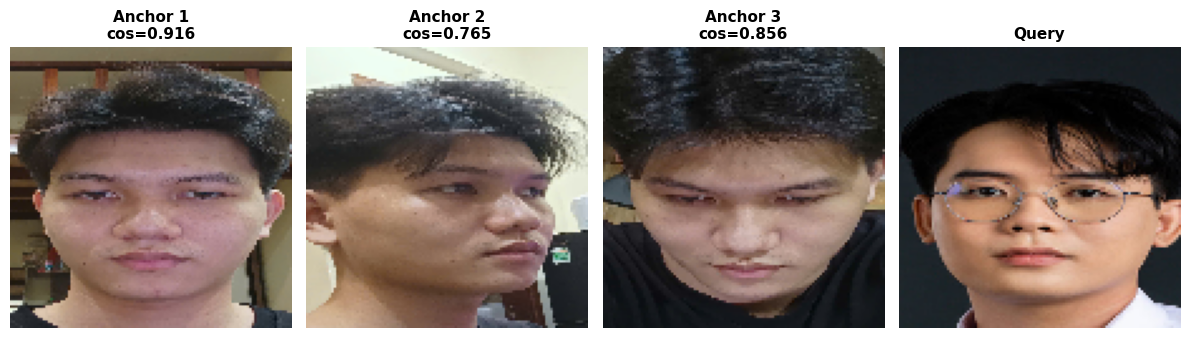

In [5]:
# Multi-Anchor Verification with MTCNN Alignment
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

from models.face_recognition.siamese.model import build_backbone
from shared.face_preprocessing import preprocess_face

RESULTS = "models/face_recognition/siamese/results"

def get_embedding_and_face(backbone, img_path):
    img = preprocess_face(img_path)
    emb = backbone.predict(img, verbose=0)
    emb = emb / (np.linalg.norm(emb, axis=1, keepdims=True) + 1e-12)
    return emb.flatten(), img[0]

backbone = build_backbone(
    input_shape=(112, 112, 3), embedding_dim=512,
    dropout_rate=CONFIG['dropout'],
    name="Inference",
)
backbone.load_weights(f"{RESULTS}/best_backbone.h5")

anchor_paths = [
    r"C:\Users\Admin\Desktop\Project_DAT301m\test_one_shot\origin.jpg",
    r"C:\Users\Admin\Desktop\Project_DAT301m\test_one_shot\test1.jpg",
    r"C:\Users\Admin\Desktop\Project_DAT301m\test_one_shot\test2.jpg",
]
query_path = r"C:\Users\Admin\Desktop\Project_DAT301m\test_one_shot\test8.jpg"

anchor_results = [get_embedding_and_face(backbone, p) for p in anchor_paths]
query_emb, query_face = get_embedding_and_face(backbone, query_path)
anchor_embs = np.stack([r[0] for r in anchor_results])
anchor_faces = [r[1] for r in anchor_results]

cosines = np.dot(anchor_embs, query_emb)
avg_similarity = float(cosines.mean())
threshold = 0.40

print("Cosine from each anchor:")
for i, c in enumerate(cosines):
    print(f"  Anchor {i+1}: {c:.4f}")
print(f"Average cosine: {avg_similarity:.4f}")
print(f"Threshold: {threshold}")
print(f"Match: {avg_similarity > threshold}")

fig, axes = plt.subplots(1, 4, figsize=(12, 4))
titles = [f"Anchor {i+1}\ncos={cosines[i]:.3f}" for i in range(3)] + ["Query"]
all_faces = anchor_faces + [query_face]
for ax, face, title in zip(axes, all_faces, titles):
    display = np.clip((face / 2.0 + 0.5), 0, 1)
    display = (display * 255).astype(np.uint8)
    ax.imshow(display)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.axis("off")
plt.tight_layout()
plt.show()